# Atividade 2 - Aprendizado Supervisionado

Luís Antônio Almeida Lima Vieira
RA: 221045

#Parte 1: Projeto Prático - Previsão de Preços de Imóveis e Interpretabilidade

In [1]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split, KFold
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
from skopt import BayesSearchCV

In [3]:
database = pd.read_csv('/content/drive/MyDrive/Aprendizado_Supervisionado/housing.csv')
database.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


## Definição de funções úteis

In [4]:
def database_preprocessing(database):
   processed_database = database.copy()

   # Retira linhas que possuem valores faltantes para alguma feature
   processed_database = processed_database.dropna()

   # Encoding das variáveis categóricas
   ocean_proximity_encoding = pd.get_dummies(processed_database['ocean_proximity']).astype(int)
   # drop special characters on columns
   ocean_proximity_encoding.columns = ocean_proximity_encoding.columns.str.replace('>', '')
   ocean_proximity_encoding.columns = ocean_proximity_encoding.columns.str.replace('<', '')
   # Concat categorical encoding
   processed_database = pd.concat([processed_database, ocean_proximity_encoding], axis=1)
   processed_database = processed_database.drop(columns=['ocean_proximity'])

   # X: Features
   X = processed_database.drop(columns=['median_house_value'])
   # y: variável alvo
   y = processed_database['median_house_value']

   # Divisão do dataset em treino e teste como estratégia para generalização
   # Aqui foram separados 20% dos dados apenas teste de performance, não sendo usados no treinamento
   X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

   # Escalonamento: Aplicação de Normalização (Standard Scaler) nas colunas de features (excluindo categóricas)
   # Etapa feita separadamente para os conjuntos de treino e testes para evitar vazamento de dados
   one_hot_columns = ocean_proximity_encoding.columns.tolist()
   numerical_columns = [col for col in X_train.columns if col not in one_hot_columns]
   scaler = StandardScaler()
   X_train_scaled = X_train.copy()
   X_test_scaled = X_test.copy()
   X_train_scaled[numerical_columns] = pd.DataFrame(scaler.fit_transform(X_train[numerical_columns]), columns=numerical_columns, index=X_train.index)
   X_test_scaled[numerical_columns] = pd.DataFrame(scaler.transform(X_test[numerical_columns]), columns=numerical_columns, index=X_test.index)

   processed_database_train = pd.concat([X_train_scaled.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
   processed_database_test = pd.concat([X_test_scaled.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)


   return processed_database, processed_database_train, processed_database_test


def get_model_scoring():
  return {
      'RMSE': make_scorer(lambda y_true, y_pred:  np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False),
      'R2': make_scorer(lambda y_true, y_pred: r2_score(y_true, y_pred))
  }


def get_cross_validate_results(model_name, tuner, see_param_var=''):
  param_var = {}
  if see_param_var:
    param_var = {
      see_param_var: tuner.cv_results_[f'param_{see_param_var}'].tolist(),
      "RMSE": -tuner.cv_results_['mean_test_RMSE'],
      "R2": tuner.cv_results_['mean_test_R2']
    }

  best_results = {
      f"Best Params ({model_name})": f"{tuner.best_params_}",
      f"best RMSE on CV ({model_name})": f"$ {-tuner.cv_results_['mean_test_RMSE'][tuner.best_index_]:.2f}",
      f"best R2 on CV ({model_name})": f"{tuner.cv_results_['mean_test_R2'][tuner.best_index_]:.2f}"
  }

  return best_results, param_var


def plot_validation_metrics(validation_results, param, var1, var2, model_name, x_scale='log'):
    fig, ax = plt.subplots(figsize=(10, 5))

    color = 'tab:blue'
    ax.set_xlabel(param)
    ax.set_ylabel(var1, color=color)
    ax.plot(validation_results[param], validation_results[var1], marker='o', color=color, label=var1)
    ax.tick_params(axis='y', labelcolor=color)
    if x_scale == 'log':
      ax.set_xscale('log')
    ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)

    ax2 = ax.twinx()

    color = 'tab:green'
    ax2.set_ylabel(var2, color=color)
    ax2.plot(validation_results[param], validation_results[var2], marker='s', linestyle='--', color=color, label=var2)
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()
    plt.title(f'{model_name}: {var1} and {var2} for each {param} on validation set')
    ax.legend(bbox_to_anchor=(1.1, 0.5), loc='center left')
    ax2.legend(bbox_to_anchor=(1.1, 0.57), loc='center left')
    plt.show()


## 1. Análise Exploratória e Pré-Processamento

### Informações da base de dados

In [ ]:
database.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
database.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Distribuições das variáveis


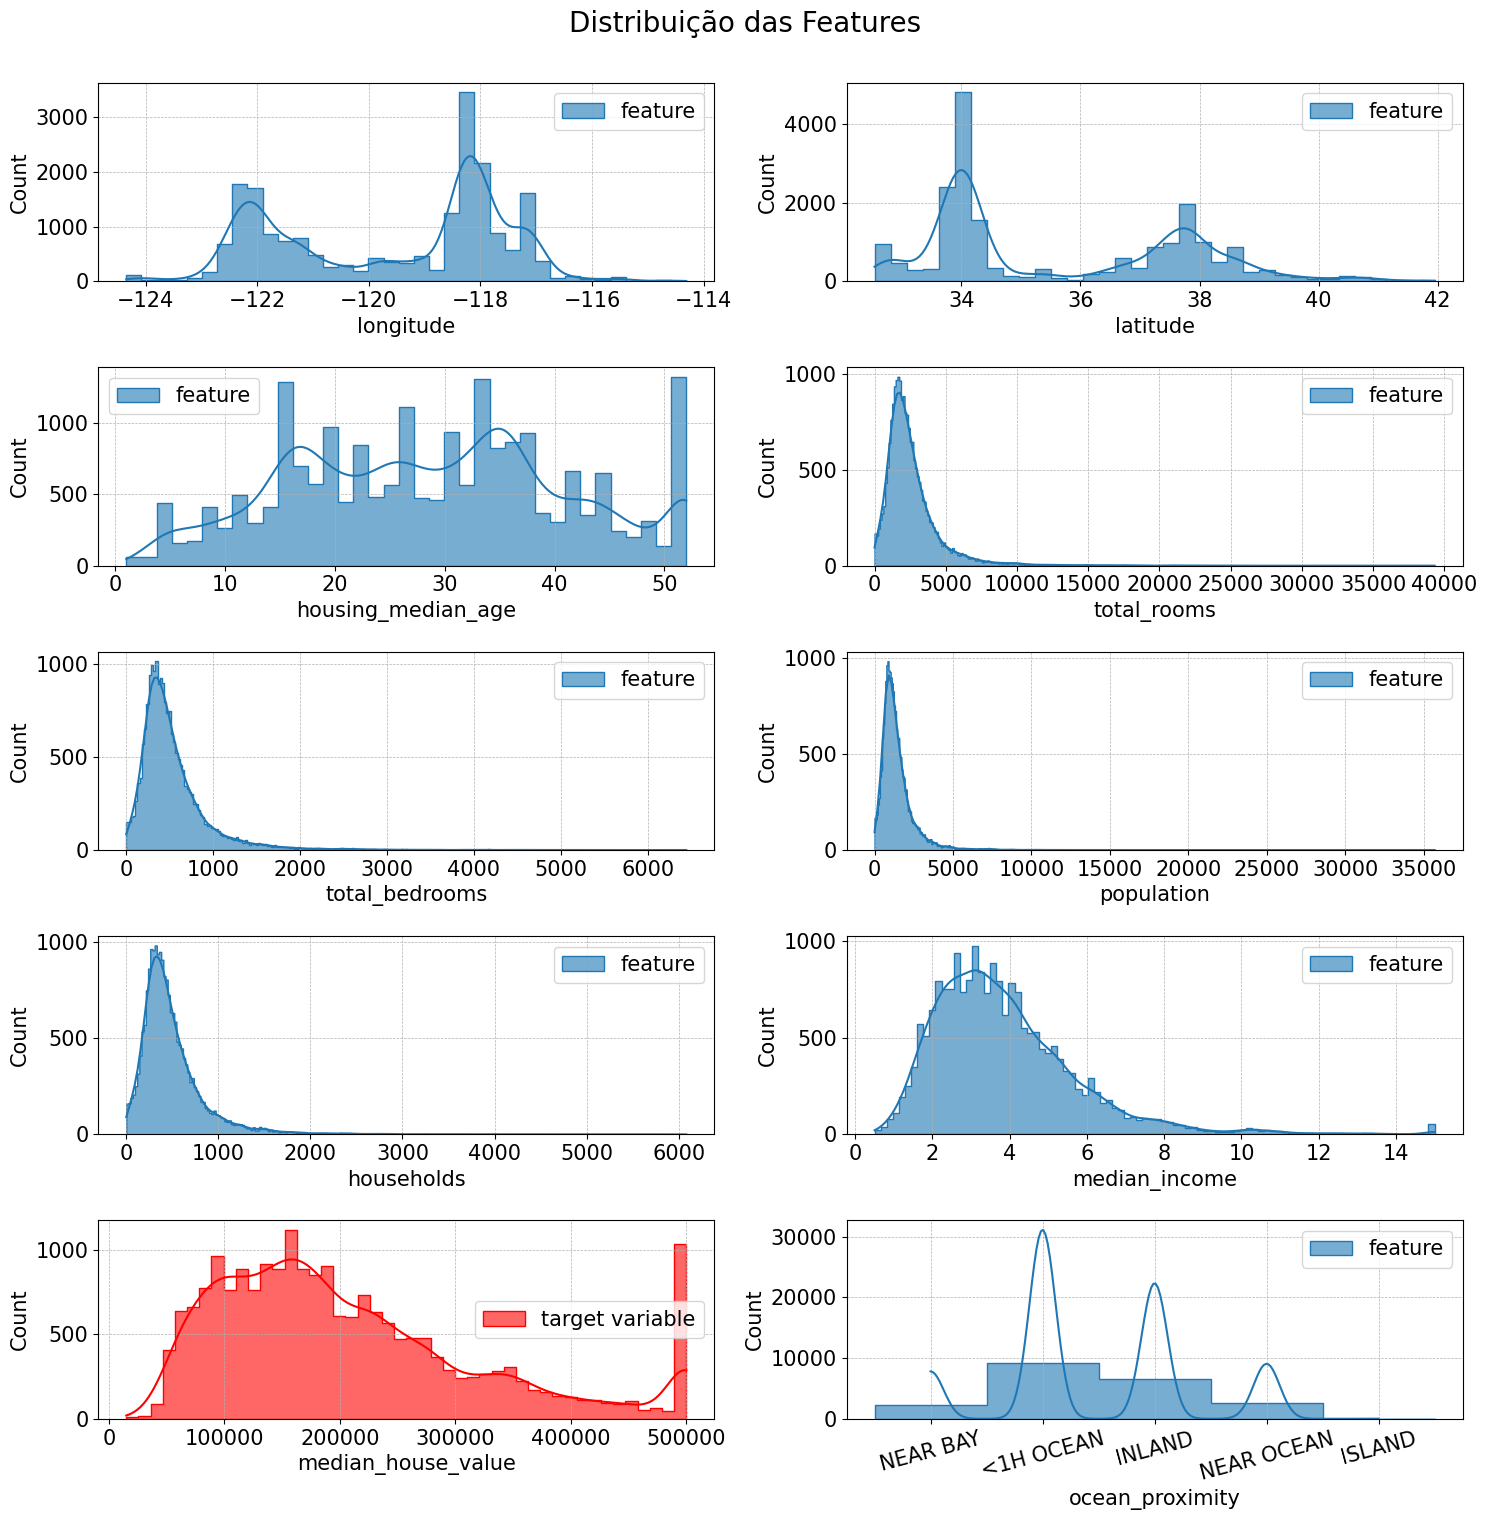

In [ ]:
fig, ax = plt.subplots(5,2, figsize=(15, 15))

plt.suptitle('Distribuição das Features', fontsize=20,  y=1.01)
for i, col in enumerate(database.columns):
  color = 'red' if col == 'median_house_value' else None
  label = 'target variable' if col == 'median_house_value' else 'feature'

  sns.histplot(
      data=database,
      x=col,
      element='step',
      kde=True,
      ax=ax.flatten()[i],
      alpha=0.6,
      color=color,
      label=label
  )
  ax.flatten()[i].grid(True, linestyle='--', linewidth=0.5)
  ax.flatten()[i].legend(fontsize=15)
  if col == 'ocean_proximity':
    ax.flatten()[i].tick_params(axis='x', labelrotation=15, labelsize=15)
  else:
    ax.flatten()[i].tick_params(axis='x', labelsize=15)
  ax.flatten()[i].tick_params(axis='y', labelsize=15)
  ax.flatten()[i].set_xlabel(col, fontsize=15)
  ax.flatten()[i].set_ylabel('Count', fontsize=15)


plt.tight_layout(h_pad=2.0)
plt.show()

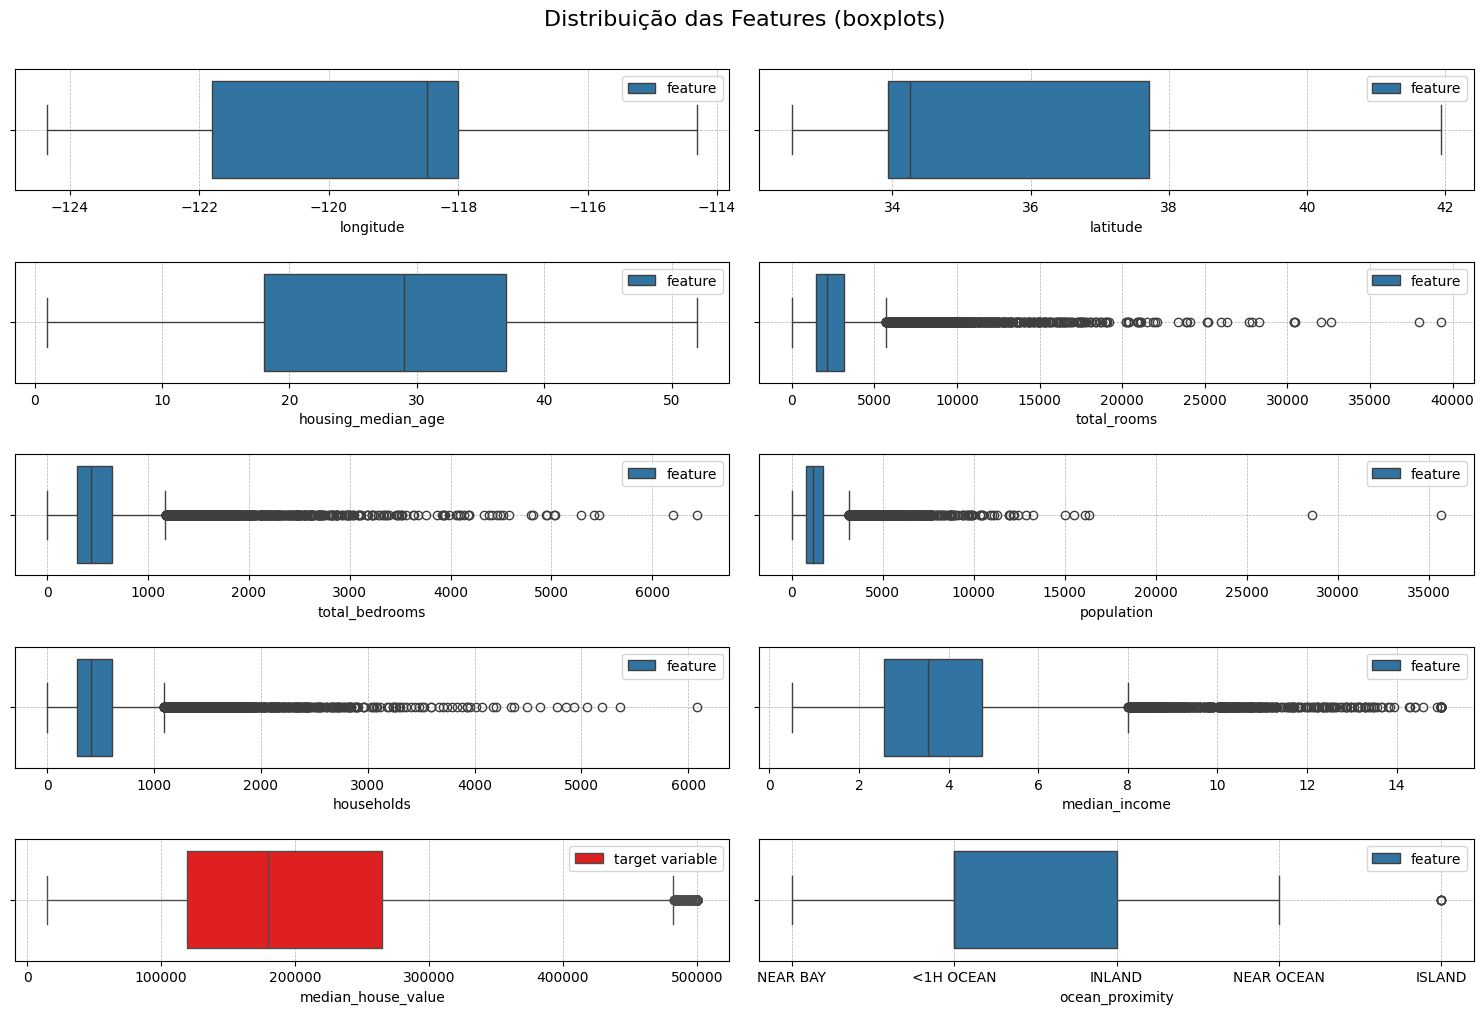

In [ ]:
fig, ax = plt.subplots(5,2, figsize=(15, 10))

plt.suptitle('Distribuição das Features (boxplots)', fontsize=16,  y=1.01)
for i, col in enumerate(database.columns):
  color = 'red' if col == 'median_house_value' else None
  label = 'target variable' if col == 'median_house_value' else 'feature'

  sns.boxplot(
      data=database,
      x=col,
      ax=ax.flatten()[i],
      color=color,
      label=label
  )
  ax.flatten()[i].grid(True, linestyle='--', linewidth=0.5)
  ax.flatten()[i].legend()


plt.tight_layout(h_pad=2.0)
plt.show()

### Correlações

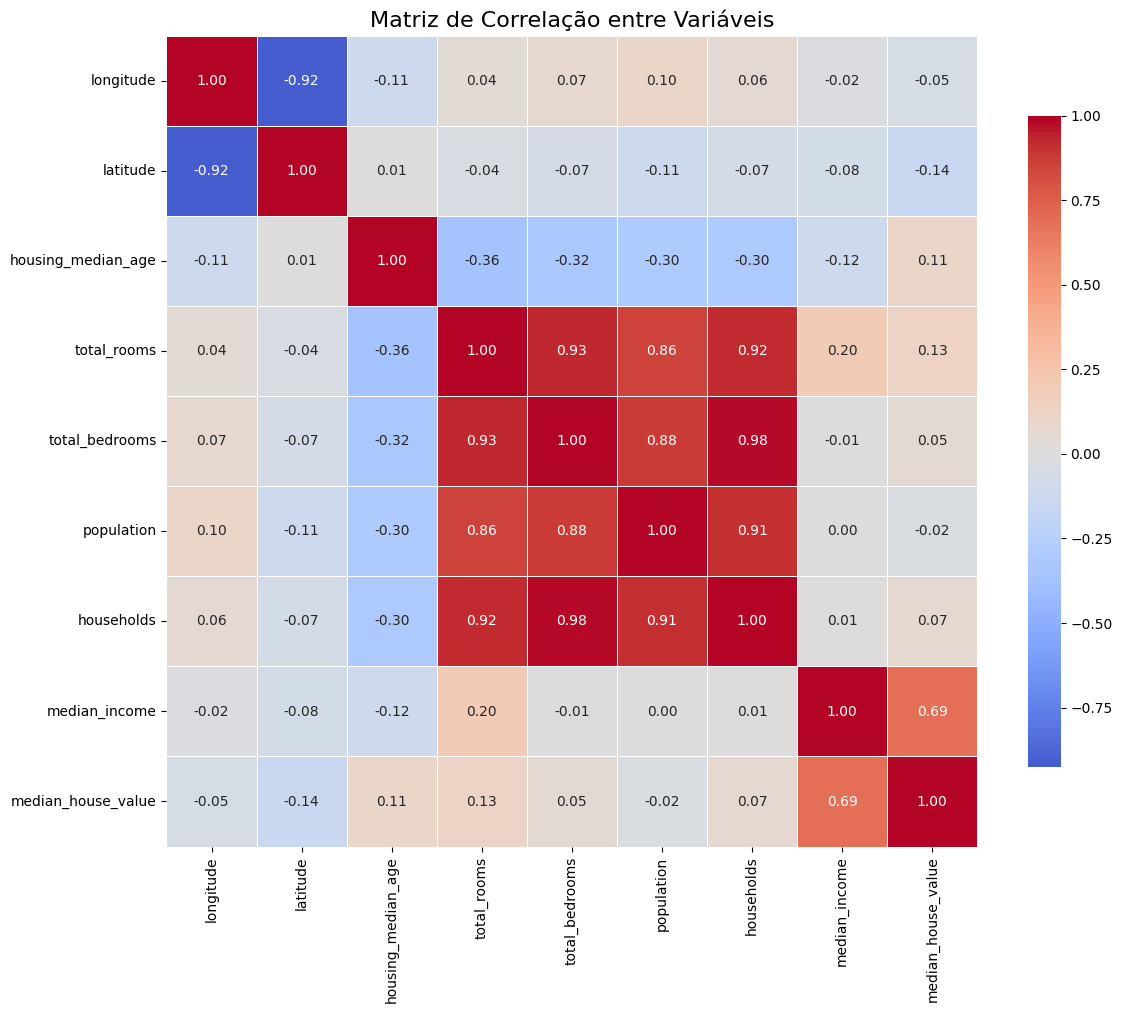

In [ ]:
correlations = database.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Matriz de Correlação entre Variáveis', fontsize=16)
plt.tight_layout()
plt.show()

### Pré-processamentos

In [ ]:
# Procurando por valores faltantes

print('Missing values:')

database.isnull().sum()

Missing values:


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [5]:
# Retirada de valores faltantes
# Encoding de features categóricas
# Divisão do dataset em treino e teste como estratégia para generalização (20% dos dados separados apenas teste de performance, não sendo usados no treinamento)
# Normalização
processed_database, processed_database_train, processed_database_test = database_preprocessing(database)
processed_database_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,median_house_value
0,-1.106514,0.786208,-1.162062,0.829311,0.929297,1.131110,1.040744,0.438412,1,0,0,0,0,227600.0
1,-0.024671,0.467873,0.348657,-0.738558,-0.850523,-0.708899,-0.856152,-0.242389,0,1,0,0,0,110400.0
2,0.758045,-0.711838,-0.287435,0.587350,0.747242,0.378459,0.691525,-0.108969,0,1,0,0,0,248100.0
3,0.633408,-0.735245,-0.048901,-0.122742,0.989183,1.185124,1.048681,-0.861168,1,0,0,0,0,305600.0
4,1.151895,-1.217429,-0.128412,-0.365632,-0.345083,-0.105008,-0.247664,-0.168986,0,0,0,0,1,214600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16341,0.802914,-0.899094,-0.366947,0.169376,-0.086375,0.014531,-0.118029,0.820914,1,0,0,0,0,273400.0
16342,1.017288,-0.880369,-1.877666,1.495284,1.195192,1.626974,1.331760,0.487838,1,0,0,0,0,160800.0
16343,0.578568,-0.763334,1.064261,-0.479414,-0.400179,-0.414923,-0.358779,-0.406634,1,0,0,0,0,335400.0
16344,-1.226165,0.903243,-1.321086,1.436303,1.264660,1.784588,1.479914,0.746774,0,0,0,1,0,231200.0


In [ ]:
processed_database_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16346 entries, 0 to 16345
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16346 non-null  float64
 1   latitude            16346 non-null  float64
 2   housing_median_age  16346 non-null  float64
 3   total_rooms         16346 non-null  float64
 4   total_bedrooms      16346 non-null  float64
 5   population          16346 non-null  float64
 6   households          16346 non-null  float64
 7   median_income       16346 non-null  float64
 8   1H OCEAN            16346 non-null  int64  
 9   INLAND              16346 non-null  int64  
 10  ISLAND              16346 non-null  int64  
 11  NEAR BAY            16346 non-null  int64  
 12  NEAR OCEAN          16346 non-null  int64  
 13  median_house_value  16346 non-null  float64
dtypes: float64(9), int64(5)
memory usage: 1.7 MB


In [ ]:
processed_database_test

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,median_house_value
0,1.166852,-1.334464,-0.684993,-0.773389,-0.618165,-0.793019,-0.644504,-0.361950,0,0,0,0,1,245800.0
1,-0.852256,1.109224,-2.116201,1.753964,1.389223,1.688071,1.215354,0.324805,0,1,0,0,0,137900.0
2,0.718161,-0.805466,0.189634,0.513044,0.759220,0.790203,0.802640,-0.340925,1,0,0,0,0,218200.0
3,-1.241122,1.076455,0.110122,-0.634529,-0.622956,-0.631863,-0.731809,-0.515710,0,0,0,1,0,220800.0
4,-1.151383,1.099862,-1.957178,-0.211446,0.145984,-0.436174,-0.096865,0.121671,0,1,0,0,0,170500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4082,0.713175,-0.880369,0.587192,0.134544,0.596329,-0.210379,0.665069,-0.143430,0,0,0,0,1,500001.0
4083,0.812885,-0.753971,0.348657,-0.392104,-0.340292,0.085368,-0.321741,-0.280222,1,0,0,0,0,157900.0
4084,0.274456,-0.150071,-1.321086,0.043983,0.031003,-0.112092,0.067163,-0.691970,0,1,0,0,0,100200.0
4085,1.077113,-0.730564,-0.048901,-0.151536,-0.280406,-0.096153,-0.141840,-0.203553,0,1,0,0,0,127700.0


In [ ]:
processed_database_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4087 entries, 0 to 4086
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           4087 non-null   float64
 1   latitude            4087 non-null   float64
 2   housing_median_age  4087 non-null   float64
 3   total_rooms         4087 non-null   float64
 4   total_bedrooms      4087 non-null   float64
 5   population          4087 non-null   float64
 6   households          4087 non-null   float64
 7   median_income       4087 non-null   float64
 8   1H OCEAN            4087 non-null   int64  
 9   INLAND              4087 non-null   int64  
 10  ISLAND              4087 non-null   int64  
 11  NEAR BAY            4087 non-null   int64  
 12  NEAR OCEAN          4087 non-null   int64  
 13  median_house_value  4087 non-null   float64
dtypes: float64(9), int64(5)
memory usage: 447.1 KB


In [6]:
# Dados de teinamento
X_train = processed_database_train.drop(columns=['median_house_value'])
y_train = processed_database_train['median_house_value']

# Dados de teste
X_test = processed_database_test.drop(columns=['median_house_value'])
y_test = processed_database_test['median_house_value']

In [7]:
# Definição da validação cruzada (5 pastas do conjunto de treinamento para para validação durante o treinamento)
cross_validate = KFold(n_splits=5, shuffle=True, random_state=42)

## 2. Abordagem 1: Modelos Lineares e Support Vector Regression (SVR)

### Regressão Linear com regularização Ridge

- Tuning de hiperparâmetros

In [ ]:
# Coeficientes de regularização a serem testados
ridge_search_space = {'alpha': [0.0001, 0.01, 0.1, 1.0, 10, 100, 1000, 10000]}

# Modelo
Ridge_regressor = Ridge()

# Busca de melhores hiperparâmetros em grade
ridge_tuner = GridSearchCV(
    Ridge_regressor,
    ridge_search_space,
    scoring=get_model_scoring(),
    refit='RMSE',
    cv=cross_validate
)

# Treinando o modelo para encontrar os hiperparâmetros ótimos
ridge_tuner.fit(X_train, y_train)

# Performance no conjunto de validação
best_results, param_var = get_cross_validate_results('Ridge Regressor', ridge_tuner, see_param_var = 'alpha')
best_results

{'Best Params (Ridge Regressor)': "{'alpha': 0.0001}",
 'best RMSE on CV (Ridge Regressor)': '$ 68718.95',
 'best R2 on CV (Ridge Regressor)': '0.64'}

In [ ]:
param_var

{'alpha': [0.0001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0],
 'RMSE': array([68718.95065172, 68719.05904697, 68720.1291169 , 68731.83901013,
        68763.00484028, 68800.48840016, 69936.39486596, 82347.64645252]),
 'R2': array([0.64290964, 0.64290858, 0.64289803, 0.64278153, 0.64247205,
        0.64212107, 0.63033695, 0.48758083])}

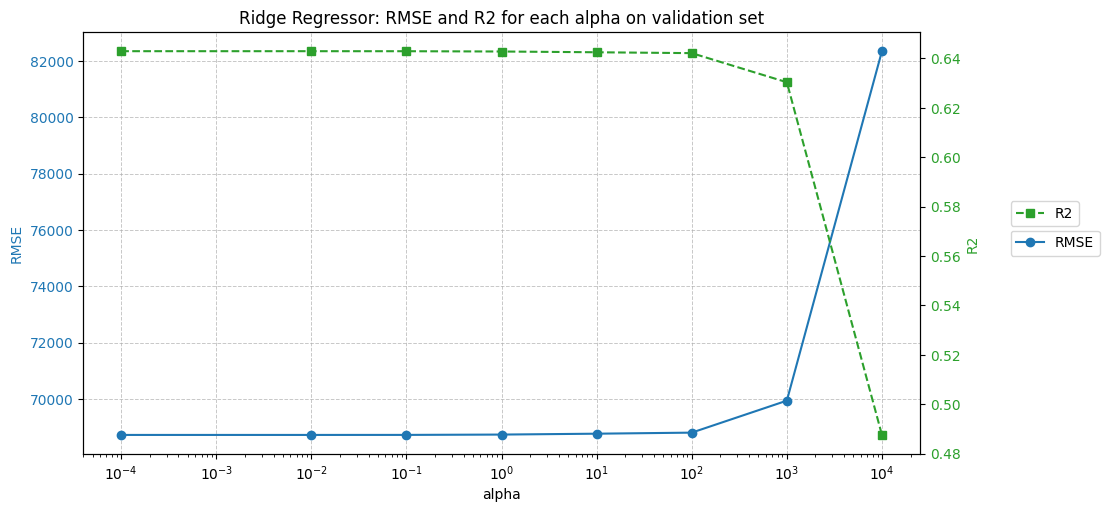

In [ ]:
plot_validation_metrics(param_var, 'alpha', 'RMSE', 'R2', 'Ridge Regressor')


### Support Vector Regression (SVR)

- Tuning de hiperparâmetros

In [ ]:
# Hiperparâmetros a serem testados

svr_search_space = {
    'C': (1e-2, 1e3, 'log-uniform'), # Variando de 1e-2 a 1e3 em escala logaritmica
    'epsilon': (0.01, 1.0, 'uniform'), # Variando de 0.01 até 1 uniformemente
    'kernel': ['linear', 'rbf'] # Teste de Kernel linear e RBF
}

# Modelo
svr_regressor = SVR()

# Busca de melhores hiperparâmetros
svr_tuner = BayesSearchCV(
    estimator=svr_regressor,
    search_spaces=svr_search_space,
    scoring=get_model_scoring(),
    refit='RMSE',
    cv=cross_validate,
    n_iter=50,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


# Treinando o modelo para encontrar os hiperparâmetros ótimos
svr_tuner.fit(X_train, y_train)

# Performance no conjunto de validação
best_results, param_var = get_cross_validate_results('Support Vector Regression (SVR)', svr_tuner)
best_results

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1000.0, 0.01, np.str_('linear')] before, using random point [665.1269893202228, 0.1921710130654625, 'linear']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1000.0, 0.01, np.str_('linear')] before, using random point [0.03202826650756277, 0.7860918514681727, 'rbf']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


...

/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1000.0, 1.0, np.str_('linear')] before, using random point [878.8473624935848, 0.5307795132046725, 'linear']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1000.0, 1.0, np.str_('linear')] before, using random point [781.312182000732, 0.6005411981732336, 'rbf']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


{'Best Params (Support Vector Regression (SVR))': "OrderedDict([('C', 1000.0), ('epsilon', 0.01), ('kernel', 'linear')])",
 'best RMSE on CV (Support Vector Regression (SVR))': '$ 69994.39',
 'best R2 on CV (Support Vector Regression (SVR))': '0.63'}

In [ ]:
best_results

{'Best Params (Support Vector Regression (SVR))': "OrderedDict([('C', 1000.0), ('epsilon', 0.01), ('kernel', 'linear')])",
 'best RMSE on CV (Support Vector Regression (SVR))': '$ 69994.39',
 'best R2 on CV (Support Vector Regression (SVR))': '0.63'}

- Impacto do hiperparâmetro C (regularização)


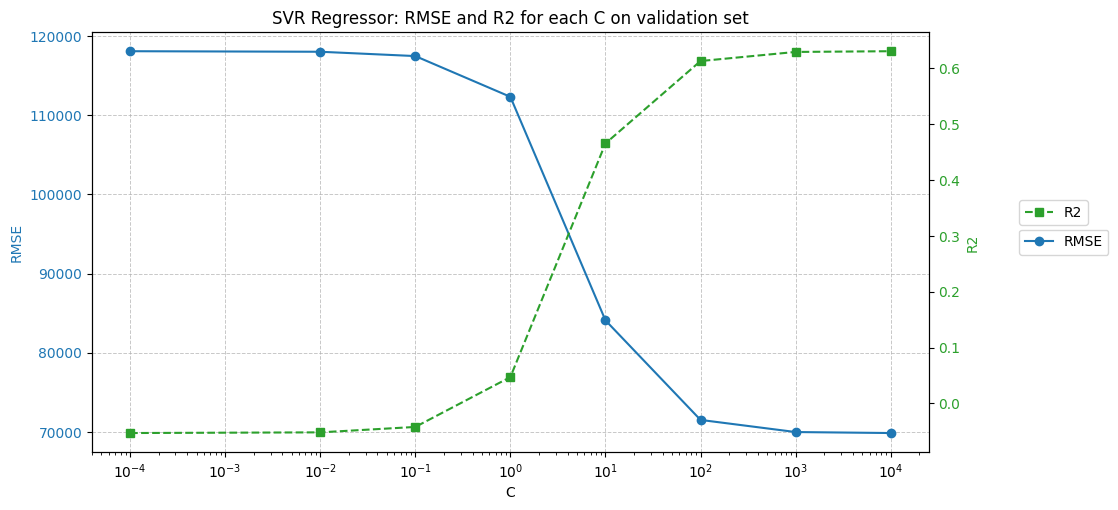

In [ ]:
# Impacto do hiperparâmetro C (regularização)
svr_search_space = {
    'C': [0.0001, 0.01, 0.1, 1.0, 10, 100, 1000, 10000],
}

# Modelo
svr_regressor = SVR(kernel='linear', epsilon=0.01)

# Busca de melhores hiperparâmetros em grade
svr_tuner = GridSearchCV(
    svr_regressor,
    svr_search_space,
    scoring=get_model_scoring(),
    refit='RMSE',
    cv=cross_validate
)

# Treinando o modelo para encontrar os hiperparâmetros ótimos
svr_tuner.fit(X_train, y_train)

# Performance no conjunto de validação
best_results, param_var = get_cross_validate_results('SVR Regressor', svr_tuner, see_param_var = 'C')

plot_validation_metrics(param_var, 'C', 'RMSE', 'R2', 'SVR Regressor')


In [ ]:
best_results

{'Best Params (SVR Regressor)': "{'C': 10000}",
 'best RMSE on CV (SVR Regressor)': '$ 69869.71',
 'best R2 on CV (SVR Regressor)': '0.63'}

- Impacto do hiperparâmetro epsilon (margem de insensibilidade)

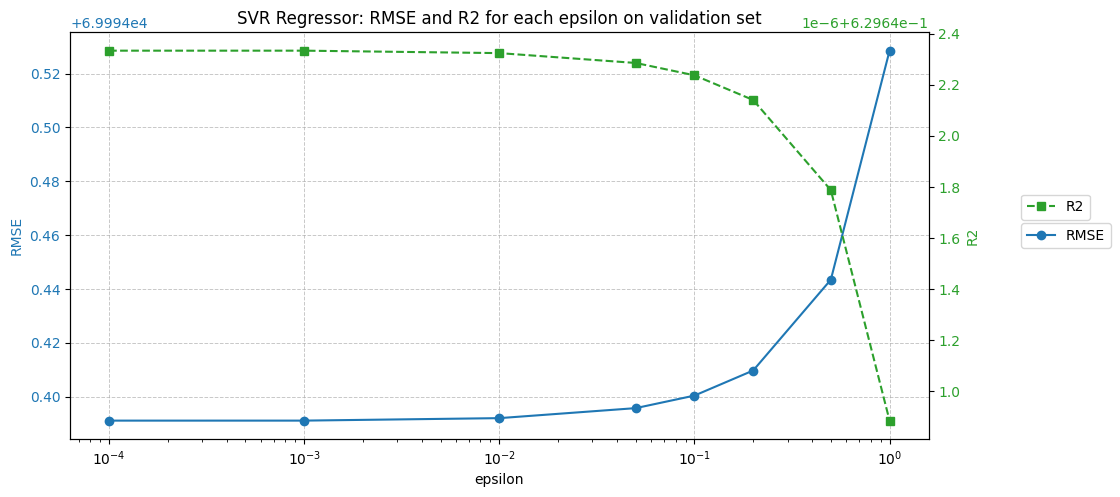

In [ ]:
# Impacto do hiperparâmetro epsilon (margem de insensibilidade)
svr_search_space = {
    'epsilon': [1e-4, 1e-3, 1e-2, 0.05, 0.1, 0.2, 0.5, 1.0],
}

# Modelo
svr_regressor = SVR(kernel='linear', C=1000.0)

# Busca de melhores hiperparâmetros em grade
svr_tuner = GridSearchCV(
    svr_regressor,
    svr_search_space,
    scoring=get_model_scoring(),
    refit='RMSE',
    cv=cross_validate
)

# Treinando o modelo para encontrar os hiperparâmetros ótimos
svr_tuner.fit(X_train, y_train)

# Performance no conjunto de validação
best_results, param_var = get_cross_validate_results('SVR Regressor', svr_tuner, see_param_var = 'epsilon')

plot_validation_metrics(param_var, 'epsilon', 'RMSE', 'R2', 'SVR Regressor', x_scale='')


In [ ]:
param_var

{'epsilon': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0],
 'RMSE': array([69994.39108384, 69994.39108702, 69994.39200659, 69994.39572414,
        69994.40038278, 69994.40970072, 69994.44342422, 69994.5284965 ]),
 'R2': array([0.62964233, 0.62964233, 0.62964232, 0.62964228, 0.62964224,
        0.62964214, 0.62964179, 0.62964089])}

In [ ]:
best_results

{'Best Params (SVR Regressor)': "{'epsilon': 0.0001}",
 'best RMSE on CV (SVR Regressor)': '$ 69994.39',
 'best R2 on CV (SVR Regressor)': '0.63'}

- Impacto dos tipos de kernel

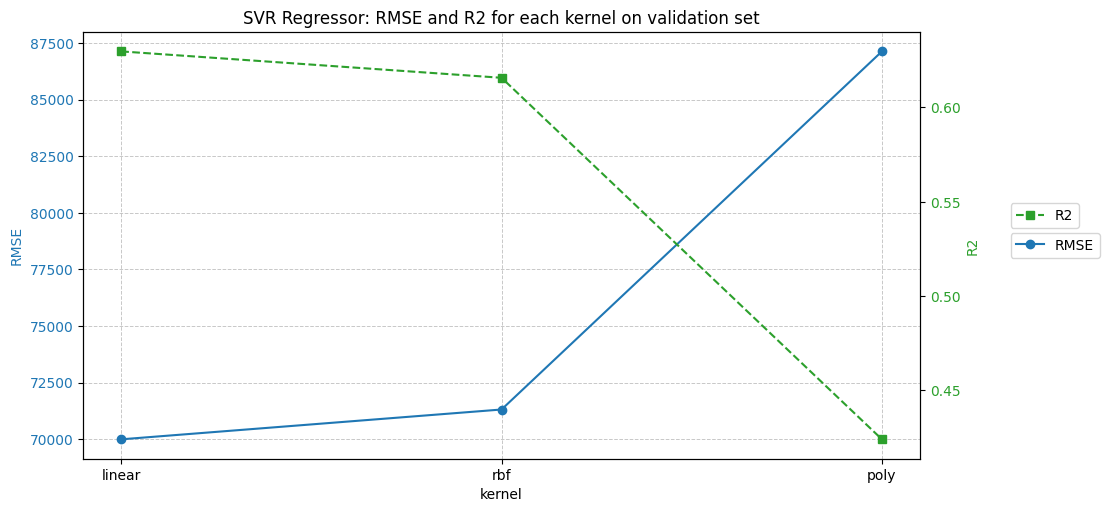

In [ ]:
# Impacto do hiperparâmetro kernel (tipos de kernel)
svr_search_space = {
    'kernel': ['linear', 'rbf', 'poly']
}

# Modelo
svr_regressor = SVR(epsilon=0.01, C=1000.0)

# Busca de melhores hiperparâmetros em grade
svr_tuner = GridSearchCV(
    svr_regressor,
    svr_search_space,
    scoring=get_model_scoring(),
    refit='RMSE',
    cv=cross_validate
)

# Treinando o modelo para encontrar os hiperparâmetros ótimos
svr_tuner.fit(X_train, y_train)

# Performance no conjunto de validação
best_results, param_var = get_cross_validate_results('SVR Regressor', svr_tuner, see_param_var = 'kernel')

plot_validation_metrics(param_var, 'kernel', 'RMSE', 'R2', 'SVR Regressor', x_scale='')

## 3. Abordagem 2: Modelos de Ensemble Baseados em Arvores

### Random Forest Regressor

In [ ]:
# Coeficientes de regularização a serem testados

rf_search_space = {
    'n_estimators': (50, 500, 'uniform'),
    'max_depth': (3, 30, 'uniform'),
    'min_samples_split': (2, 20, 'uniform'),
    'min_samples_leaf': (1, 10, 'uniform'),
    'max_features': ['sqrt', 'log2', None]
}

# Modelo
rf_regressor = RandomForestRegressor(random_state=42)

# Busca de melhores hiperparâmetros em grade
rf_tuner = BayesSearchCV(
    estimator=rf_regressor,
    search_spaces=rf_search_space,
    scoring=get_model_scoring(),
    refit='RMSE',
    cv=cross_validate,
    n_iter=50,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


# Treinando o modelo para encontrar os hiperparâmetros ótimos
rf_tuner.fit(X_train, y_train)

# Performance no conjunto de validação
best_results, param_var = get_cross_validate_results('Random Forest', rf_tuner)
best_results

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


...

/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(25), np.str_('sqrt'), np.int64(1), np.int64(2), np.int64(500)] before, using random point [np.int64(21), 'log2', np.int64(3), np.int64(18), np.int64(475)]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(23), None, np.int64(1), np.int64(2), np.int64(500)] before, using random point [np.int64(20), 'sqrt', np.int64(3), np.int64(12), np.int64(496)]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


{'Best Params (Random Forest)': "OrderedDict([('max_depth', 23), ('max_features', None), ('min_samples_leaf', 2), ('min_samples_split', 5), ('n_estimators', 410)])",
 'best RMSE on CV (Random Forest)': '$ 48820.07',
 'best R2 on CV (Random Forest)': '0.82'}

In [ ]:
best_results

{'Best Params (Random Forest)': "OrderedDict([('max_depth', 23), ('max_features', None), ('min_samples_leaf', 2), ('min_samples_split', 5), ('n_estimators', 410)])",
 'best RMSE on CV (Random Forest)': '$ 48820.07',
 'best R2 on CV (Random Forest)': '0.82'}

### Gradient Boosting Regressor

In [ ]:
# Coeficientes de regularização a serem testados

xgb_search_space = {
    'n_estimators': (50, 500, 'uniform'),
    'max_depth': (3, 15, 'uniform'),
    'learning_rate': (0.01, 0.3, 'uniform'),
    'subsample': (0.5, 1.0, 'uniform'),
    'colsample_bytree': (0.5, 1.0, 'uniform'),
    'min_child_weight': (1, 10, 'uniform')
}

# Modelo
xgb_regressor = XGBRegressor(random_state=42, use_label_encoder=False, eval_metric='rmse')

# Busca de melhores hiperparâmetros em grade
xgb_tuner = BayesSearchCV(
    estimator=xgb_regressor,
    search_spaces=xgb_search_space,
    scoring=get_model_scoring(),
    refit='RMSE',
    cv=cross_validate,
    n_iter=50,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


# Treinando o modelo para encontrar os hiperparâmetros ótimos
xgb_tuner.fit(X_train, y_train)

# Performance no conjunto de validação
best_results, param_var = get_cross_validate_results('Gradient Boosting Regressor (XGBoost)', xgb_tuner)
best_results

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:12:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


{'Best Params (Gradient Boosting Regressor (XGBoost))': "OrderedDict([('colsample_bytree', 0.9216679429119221), ('learning_rate', 0.04947390997061391), ('max_depth', 10), ('min_child_weight', 6), ('n_estimators', 238), ('subsample', 0.719219215877656)])",
 'best RMSE on CV (Gradient Boosting Regressor (XGBoost))': '$ 45523.40',
 'best R2 on CV (Gradient Boosting Regressor (XGBoost))': '0.84'}

In [ ]:
best_results

{'Best Params (Gradient Boosting Regressor (XGBoost))': "OrderedDict([('colsample_bytree', 0.9216679429119221), ('learning_rate', 0.04947390997061391), ('max_depth', 10), ('min_child_weight', 6), ('n_estimators', 238), ('subsample', 0.719219215877656)])",
 'best RMSE on CV (Gradient Boosting Regressor (XGBoost))': '$ 45523.40',
 'best R2 on CV (Gradient Boosting Regressor (XGBoost))': '0.84'}

## 4. Interpretação e Comparação Final

### Performance no conjunto de testes

- Regressão Linear com regularização Ridge

In [ ]:
ridge_regressor = Ridge(alpha=0.0001)
ridge_regressor.fit(X_train, y_train)

y_pred_test = ridge_regressor.predict(X_test)

print(f"Ridge Regressor test set RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"Ridge Regressor test set R2: {r2_score(y_test, y_pred_test):.2f}")

Ridge Regressor test set RMSE: 69297.71
Ridge Regressor test set R2: 0.65


- Support Vector Regression (SVR)

In [ ]:
svr_regressor = SVR(C=1000.0, epsilon=0.01, kernel='linear')
svr_regressor.fit(X_train, y_train)

y_pred_test = svr_regressor.predict(X_test)

print(f"SVR test set RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"SVR test set R2: {r2_score(y_test, y_pred_test):.2f}")

SVR test set RMSE: 70874.86
SVR test set R2: 0.63


- Random Forest Regressor

In [ ]:
rf_regressor = RandomForestRegressor(
    max_depth=23,
    max_features=None,
    min_samples_leaf=2,
    min_samples_split=5,
    n_estimators=410,
    random_state=42
)
rf_regressor.fit(X_train, y_train)

y_pred_test = rf_regressor.predict(X_test)

print(f"Random Forest test set RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"Random Forest test set R2: {r2_score(y_test, y_pred_test):.2f}")

Random Forest test set RMSE: 48586.89
Random Forest test set R2: 0.83


- Gradient Boosting Regressor

In [ ]:
gb_regressor = XGBRegressor(
    colsample_bytree=0.9216679429119221,
    learning_rate=0.04947390997061391,
    max_depth=10,
    min_child_weight=6,
    n_estimators=238,
    subsample=0.719219215877656,
    random_state=42
)
gb_regressor.fit(X_train, y_train)

y_pred_test = gb_regressor.predict(X_test)

print(f"Gradient Boosting test set RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"Gradient Boosting test set R2: {r2_score(y_test, y_pred_test):.2f}")

Gradient Boosting test set RMSE: 46176.13
Gradient Boosting test set R2: 0.84


### Análise de Interpretabilidade

In [8]:
# Melhor modelo
gb_regressor = XGBRegressor(
    colsample_bytree=0.9216679429119221,
    learning_rate=0.04947390997061391,
    max_depth=10,
    min_child_weight=6,
    n_estimators=238,
    subsample=0.719219215877656,
    random_state=42
)
_ = gb_regressor.fit(X_train, y_train)

- Importância das Features

In [9]:
feature_importances = pd.Series(
    gb_regressor.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importances


,0
INLAND,0.661264
median_income,0.120173
NEAR OCEAN,0.042378
NEAR BAY,0.037011
longitude,0.027252
1H OCEAN,0.027250
latitude,0.025223
housing_median_age,0.015558
population,0.013621
total_rooms,0.011141


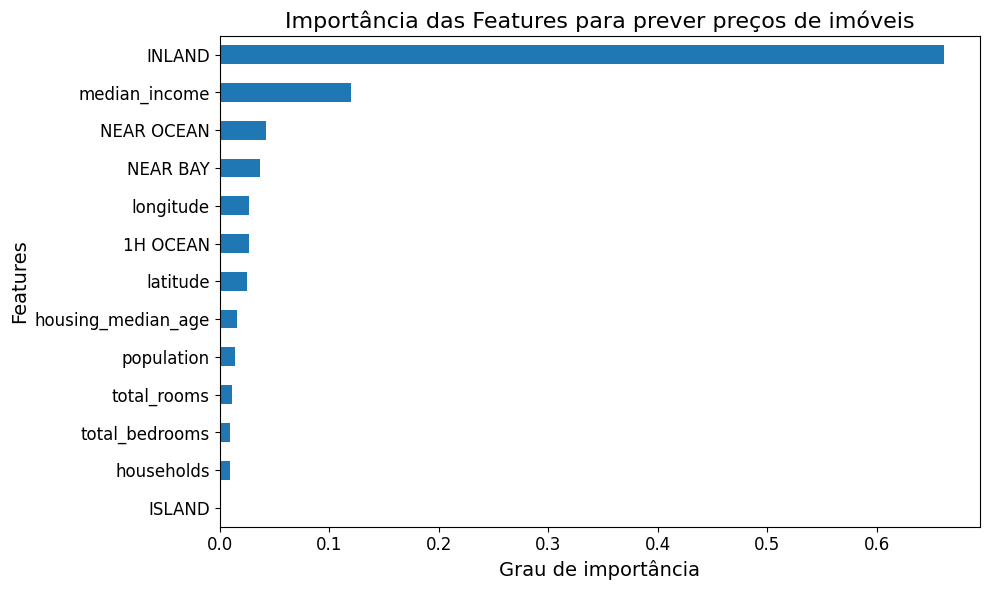

In [10]:
plt.figure(figsize=(10, 6))
feature_importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Importância das Features para prever preços de imóveis", fontsize=16)
plt.xlabel("Grau de importância", fontsize=14)
plt.ylabel("Features", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

- Gráficos de dependência parcial (PDPs)

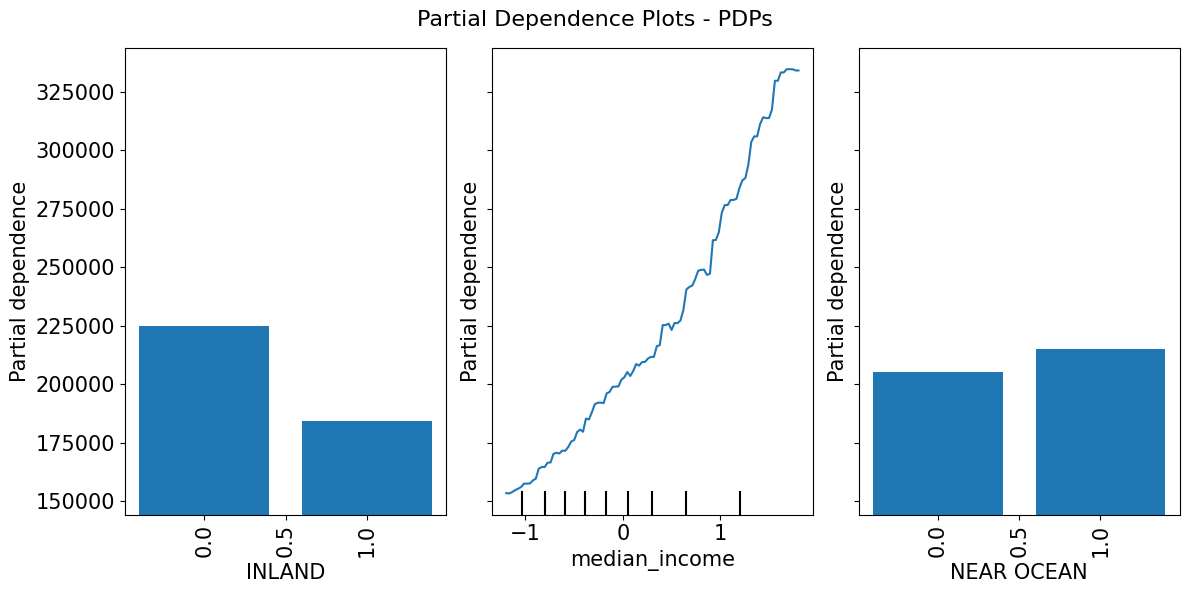

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(12, 6), sharey=True)
PartialDependenceDisplay.from_estimator(
    gb_regressor,
    X_train,
    features=feature_importances[:3].index.to_list(),
    kind='average',
    categorical_features = ['1H OCEAN','INLAND','ISLAND','NEAR BAY','NEAR OCEAN'],
    ax=ax
)

# Aumentar fontes dos títulos e labels de cada subplot
for axis in ax:
    axis.set_title(axis.get_title(), fontsize=15)
    axis.set_xlabel(axis.get_xlabel(), fontsize=15)
    axis.set_ylabel(axis.get_ylabel(), fontsize=15)
    axis.tick_params(labelsize=15)

plt.suptitle("Partial Dependence Plots - PDPs", fontsize=16)
plt.tight_layout()
plt.show()